# Chapter 3


## Lab: Linear Regression


In [3]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

In [5]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.anova import anova_lm

In [7]:
from ISLP import load_data
from ISLP.models import (ModelSpec as MS,
                         summarize,
                         poly)

### Simple Linear Regression

In [12]:
Boston = load_data('Boston')
Boston.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'lstat', 'medv'],
      dtype='object')

In [13]:
Boston?

Type:        DataFrame
String form:
crim    zn  indus  chas    nox  ...  rad  tax  ptratio  lstat  medv
           0    0.00632  18.0    <...>   0.04741   0.0  11.93     0  0.573  ...    1  273     21.0   7.88  11.9
           
           [506 rows x 13 columns]
Length:      506
File:        f:\python\islp\islp_env\lib\site-packages\pandas\core\frame.py
Docstring:  
Two-dimensional, size-mutable, potentially heterogeneous tabular data.

Data structure also contains labeled axes (rows and columns).
Arithmetic operations align on both row and column labels. Can be
thought of as a dict-like container for Series objects. The primary
pandas data structure.

Parameters
----------
data : ndarray (structured or homogeneous), Iterable, dict, or DataFrame
    Dict can contain Series, arrays, constants, dataclass or list-like objects. If
    data is a dict, column order follows insertion-order. If a dict contains Series
    which have an index defined, it is aligned by its index. This alignment a

In [14]:
Boston.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


In [ ]:
X = pd.DataFrame({'intercept': np.ones(Boston.shape[0]),
                  'lstat': Boston['lstat']})
# in this model, the only predictor is lstat, and response is medv 
# the intercept is added to make the model work, but it is not a predictor and it is always taken as 1
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [ ]:
y = Boston['medv']
model = sm.OLS(y, X)
#OLS stands for ordinary least squares, which is the method used to fit the linear regression model
results = model.fit()

In [ ]:
summarize(results)
#according to result the eqn is medv = 34.55 - 0.95*lstat

,coef,std err,t,P>|t|
intercept,34.5538,0.563,61.415,0.0
lstat,-0.9500,0.039,-24.528,0.0


### Using Transformations: Fit and Transform

In [ ]:
design = MS(['lstat'])
design = design.fit(Boston)
X = design.transform(Boston)
# these two operation can be combined with fit_transform() method, which is more efficient
#X = design.fit_transform(Boston)
X[:4]

,intercept,lstat
0,1.0,4.98
1,1.0,9.14
2,1.0,4.03
3,1.0,2.94


In [23]:
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   medv   R-squared:                       0.544
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     601.6
Date:                Wed, 04 Mar 2026   Prob (F-statistic):           5.08e-88
Time:                        18:42:46   Log-Likelihood:                -1641.5
No. Observations:                 506   AIC:                             3287.
Df Residuals:                     504   BIC:                             3295.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     34.5538      0.563     61.415      0.000      33.448      35.659
lstat         -0.9500      0.039    -24.528      0.000      -1.026      -0.874
==============================================================================
Omnibus:                      137.043   Durbin-Watson:                   0.892
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              291.373
Skew:                           1.453   Prob(JB):                     5.36e-64
Kurtosis:                       5.319   Cond. No.                         29.7
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [24]:
results.params

intercept    34.553841
lstat        -0.950049
dtype: float64

In [ ]:
#we predict the response for lstat = 5, 10, 15
new_df = pd.DataFrame({'lstat': [5, 10, 15]})
newX = design.transform(new_df)
newX

,intercept,lstat
0,1.0,5
1,1.0,10
2,1.0,15


In [26]:
new_predictions = results.get_prediction(newX)
new_predictions.predicted_mean

array([29.80359411, 25.05334734, 20.30310057])

In [ ]:
new_predictions.conf_int(alpha=0.05)
#confidence interval

array([[29.00741194, 30.59977628],
       [24.47413202, 25.63256267],
       [19.73158815, 20.87461299]])

In [ ]:
new_predictions.conf_int(obs = True, alpha=0.05)
#prediction interval

array([[17.56567478, 42.04151344],
       [12.82762635, 37.27906833],
       [ 8.0777421 , 32.52845905]])

In [30]:
# Next we plot medv and lstat using DataFrame.plot.scatter() and add regression line to resulting plot
#defining fuctions

def abline(ax, b, m, *args, **kwargs):
    "Add a line with slope m and intercept b to axes ax"
    xlim = ax.get_xlim()
    ylim = [m * xlim[0] + b, m * xlim[1] + b]
    ax.plot(xlim, ylim, *args, **kwargs)

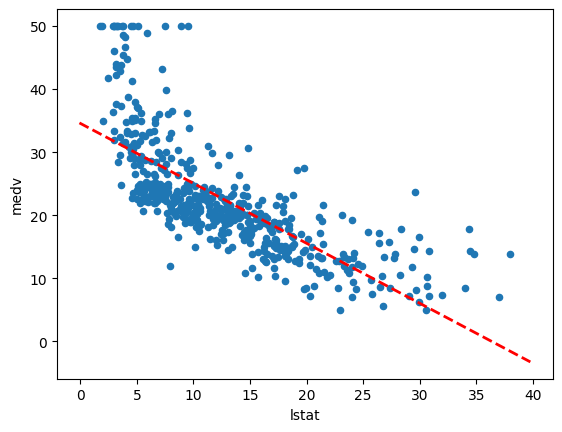

In [47]:
ax = Boston.plot.scatter('lstat', 'medv')
abline(ax,
       results.params.iloc[0],
       results.params.iloc[1],
       'r--',
       linewidth=2)

Also, there is an existing function to add a line to plot using ax.axhline(), example is shown below

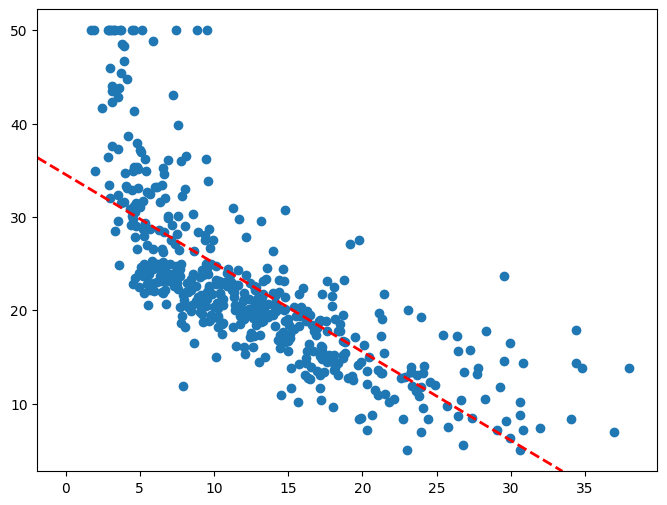

In [53]:
#axline is matplotlib function so we can't use boston.plot.scatter() which is pandas function
fig, ax = subplots(figsize=(8,6))
ax.scatter(Boston['lstat'], Boston['medv'])
ax.axline((0, results.params.iloc[0]),
          slope=results.params.iloc[1],
          color='red',
          linestyle='--',
          linewidth=2)

Next are some diagnostic plots, 

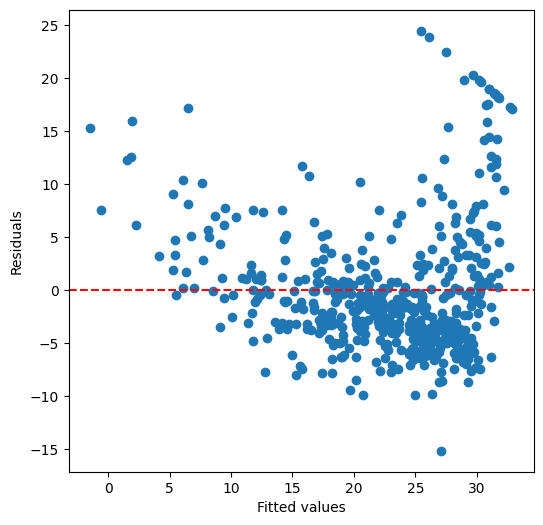

In [60]:
ax = subplots(figsize=(6,6))[1]
# [1] returns axes object where [0] returns figure object
ax.scatter(results.fittedvalues, results.resid)
#fitted values (predicted values from the regression model) and residuals (errors: actual - predicted)
ax.set_xlabel('Fitted values')
ax.set_ylabel('Residuals')
ax.axhline(0, color='red', linestyle='--')

on basis of above plot, there is evidence of some non linearity. So Leverage statistics is measured using hat_matrix_diag attributre of the value returned by get_influence() method

Leverage statistics measure how much influence each data point has on its own predicted value in a regression model. Mathematically, leverage values are the diagonal elements of the hat matrix (H), which maps observed response values to fitted values.

Key points:

- High leverage points have predictor values far from the mean of the predictors.
- Such points can strongly affect the fit of the regression model.
- Leverage values range between 0 and 1;
- Observations with high leverage deserve special attention, as they can disproportionately influence the regression results.

In summary, leverage statistics help identify data points that have the potential to be influential in determining the regression line or surface.

np.int64(374)

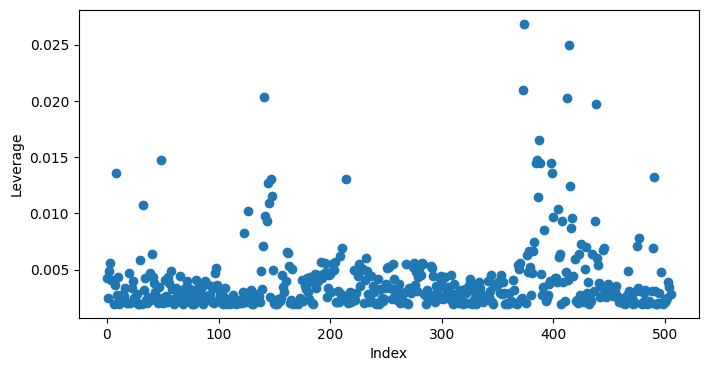

In [58]:
infl = results.get_influence()
ax = subplots(figsize=(8,4))[1]
ax.scatter(np.arange(X.shape[0]), infl.hat_matrix_diag)
ax.set_xlabel('Index')
ax.set_ylabel('Leverage')
np.argmax(infl.hat_matrix_diag)
